# Deep Learning Classification Model - Fresh Training
Training a ResNet50 model to classify fault and social issues with >90% accuracy

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # ← set to 0
    pin_memory=True     # ← speeds up GPU transfer
)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | CUDA: {torch.cuda.is_available()}')

Device: cuda | CUDA: True


In [3]:
# Load both datasets
image_paths = []
labels = []

# Dataset 1: Damaged concrete structures
dataset1_root = Path(r'd:\dl+nlp\archive (1)\Damaged concrete structures\Damaged concrete structures\test\images')
if dataset1_root.exists():
    for img_path in dataset1_root.glob('*.jpg'):
        image_paths.append(str(img_path))
        labels.append('Damaged Concrete')

# Dataset 2: Road and Environmental Issues
dataset2_root = Path(r'd:\dl+nlp\archive (2)\data')
if dataset2_root.exists():
    for class_dir in sorted(dataset2_root.rglob('*')):
        if class_dir.is_dir() and any(class_dir.glob('*.jpg')):
            class_name = class_dir.name
            for img_path in class_dir.glob('*.jpg'):
                image_paths.append(str(img_path))
                labels.append(class_name)

df = pd.DataFrame({'image_path': image_paths, 'label': labels})
print(f'Total images: {len(df)}')
print(f'\nClass distribution:')
print(df['label'].value_counts())

Total images: 10338

Class distribution:
label
Pothole Issues                               3348
Vandalism Issues                             2128
Broken Road Sign Issues                      1793
Littering Garbage on Public Places Issues    1419
Damaged Concrete                              678
Damaged Road issues                           677
Mixed Issues                                  191
Illegal Parking Issues                        104
Name: count, dtype: int64


In [4]:
# Encode labels and split dataset
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
class_names_sorted = label_encoder.classes_
num_classes = len(class_names_sorted)

# Class weights for imbalance
class_weights_array = compute_class_weight('balanced', 
                                            classes=np.unique(df['label_encoded']),
                                            y=df['label_encoded'])
class_weights = torch.from_numpy(class_weights_array).float().to(device)

# 70/15/15 split
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes: {list(class_names_sorted)}')

Train: 7236 | Val: 1551 | Test: 1551
Classes: ['Broken Road Sign Issues', 'Damaged Concrete', 'Damaged Road issues', 'Illegal Parking Issues', 'Littering Garbage on Public Places Issues', 'Mixed Issues', 'Pothole Issues', 'Vandalism Issues']


In [5]:
# Define dataset and transforms
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_encoded']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataloaders
train_dataset = CustomImageDataset(train_df, transform=train_transform)
val_dataset = CustomImageDataset(val_df, transform=val_test_transform)
test_dataset = CustomImageDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f'Dataloaders created: {len(train_loader)} train batches')

Dataloaders created: 227 train batches


In [6]:
# Build model
class ImageClassificationModel(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super(ImageClassificationModel, self).__init__()
        self.backbone = models.resnet50(pretrained=pretrained)
        
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

model = ImageClassificationModel(num_classes=num_classes, pretrained=True)
model = model.to(device)

print(f'Model initialized: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model initialized: 24,690,504 params
Trainable params: 1,182,472


## Training starts now...

In [7]:
# Setup training
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
PATIENCE = 5

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None
patience_counter = 0

def train_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(data_loader, desc='Training', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / len(data_loader), correct / total

def evaluate_epoch(model, data_loader, criterion, device, desc='Validating'):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc, leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(data_loader), correct / total

print('\n' + '='*70)
print('STARTING TRAINING - 20 EPOCHS')
print('='*70 + '\n')


STARTING TRAINING - 20 EPOCHS



In [8]:
# MAIN TRAINING LOOP
for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}')
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device, desc='Validating')
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}')
    print(f'  Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}')
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f'  ✓ Best model updated (val_acc={val_acc:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch + 1}')
        break
    print()

# Save best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, r'd:\dl+nlp\best_model_trained.pth')
    print(f'\n✓ Best model saved (val_acc={best_val_acc:.4f})')

print('\nTraining completed!')

Epoch 1/20 | LR: 1.00e-03


Training:   0%|          | 0/227 [00:00<?, ?it/s]

  Train: Loss=1.1475, Acc=0.5698
  Val:   Loss=0.5914, Acc=0.8375
  ✓ Best model updated (val_acc=0.8375)

Epoch 2/20 | LR: 1.00e-03


  Train: Loss=0.6610, Acc=0.7221
  Val:   Loss=0.4974, Acc=0.8556
  ✓ Best model updated (val_acc=0.8556)

Epoch 3/20 | LR: 1.00e-03


  Train: Loss=0.5510, Acc=0.7718
  Val:   Loss=0.4029, Acc=0.8195
  No improvement (1/5)

Epoch 4/20 | LR: 1.00e-03


...

  Train: Loss=0.3225, Acc=0.8596
  Val:   Loss=0.3630, Acc=0.8375
  No improvement (1/5)

Epoch 16/20 | LR: 2.50e-04


  Train: Loss=0.3482, Acc=0.8503
  Val:   Loss=0.3431, Acc=0.8652
  No improvement (2/5)

Epoch 17/20 | LR: 2.50e-04


  Train: Loss=0.3149, Acc=0.8583
  Val:   Loss=0.3157, Acc=0.8691
  No improvement (3/5)

Epoch 18/20 | LR: 2.50e-04


  Train: Loss=0.3112, Acc=0.8588
  Val:   Loss=0.3385, Acc=0.8627
  No improvement (4/5)

Epoch 19/20 | LR: 2.50e-04


  Train: Loss=0.3007, Acc=0.8589
  Val:   Loss=0.3498, Acc=0.8704
  No improvement (5/5)

Early stopping at epoch 19

✓ Best model saved (val_acc=0.8762)

Training completed!


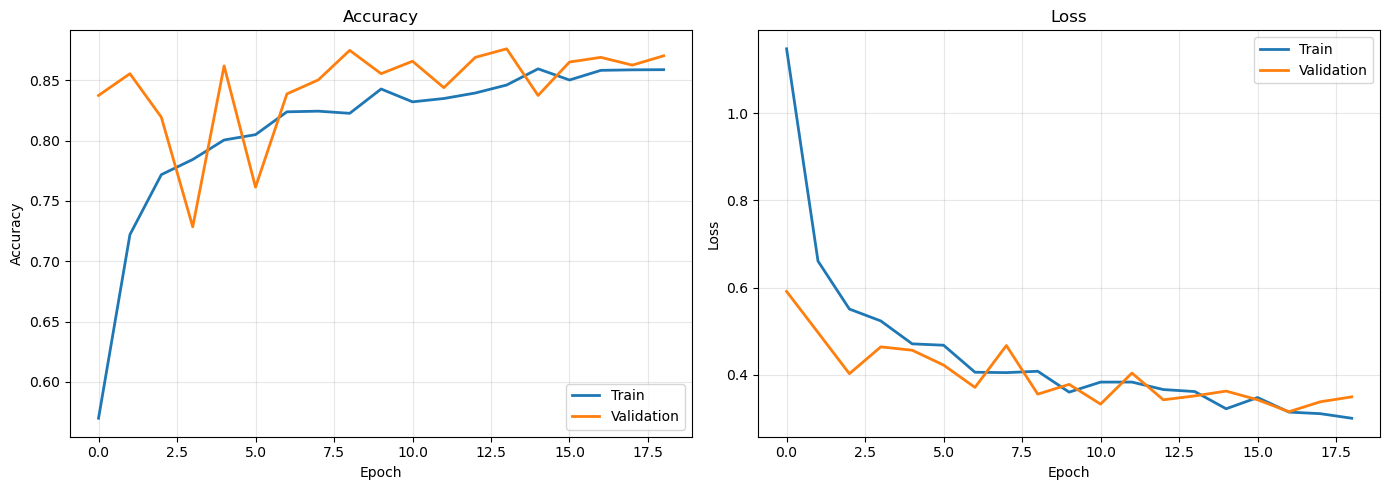

Best Val Accuracy: 0.8762


In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train', linewidth=2)
axes[0].plot(history['val_acc'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train', linewidth=2)
axes[1].plot(history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best Val Accuracy: {best_val_acc:.4f}')

In [10]:
# Evaluate on test set
print('Evaluating on test set...')
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_acc = accuracy_score(y_true, y_pred)

print('\n' + '='*70)
print('TEST SET RESULTS')
print('='*70)
print(f'Accuracy: {test_acc*100:.2f}%')

if test_acc >= 0.90:
    print('\n✓✓✓ MODEL EXCEEDS 90% ACCURACY ✓✓✓')
else:
    print(f'\nAccuracy is {test_acc*100:.2f}% (target: 90%)')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names_sorted, digits=4))

Evaluating on test set...



TEST SET RESULTS
Accuracy: 88.85%

Accuracy is 88.85% (target: 90%)

Classification Report:
                                           precision    recall  f1-score   support

                  Broken Road Sign Issues     0.9745    0.9926    0.9834       269
                         Damaged Concrete     0.9000    0.8911    0.8955       101
                      Damaged Road issues     0.8000    0.7525    0.7755       101
                   Illegal Parking Issues     0.3265    1.0000    0.4923        16
Littering Garbage on Public Places Issues     0.9891    0.8545    0.9169       213
                             Mixed Issues     0.2907    0.8621    0.4348        29
                           Pothole Issues     0.9507    0.8429    0.8936       503
                         Vandalism Issues     0.9401    0.9342    0.9371       319

                                 accuracy                         0.8885      1551
                                macro avg     0.7714    0.8912    0.7911   

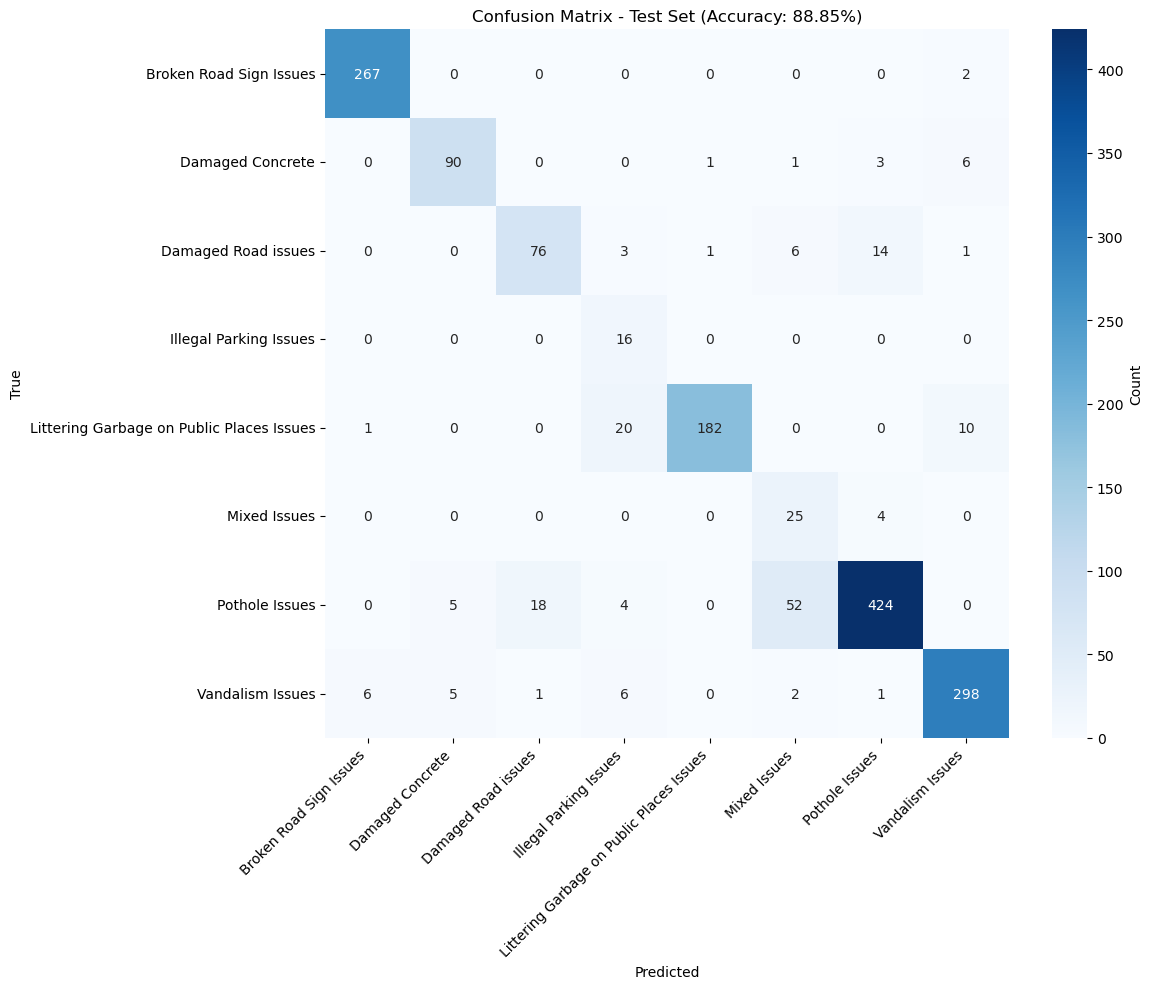

Per-class accuracy:
  Broken Road Sign Issues: 99.26%
  Damaged Concrete: 89.11%
  Damaged Road issues: 75.25%
  Illegal Parking Issues: 100.00%
  Littering Garbage on Public Places Issues: 85.45%
  Mixed Issues: 86.21%
  Pothole Issues: 84.29%
  Vandalism Issues: 93.42%


In [11]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_sorted,
            yticklabels=class_names_sorted,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Test Set (Accuracy: {test_acc*100:.2f}%)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Per-class accuracy:')
for i, class_name in enumerate(class_names_sorted):
    class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {class_name}: {class_acc*100:.2f}%')

## Phase 2: Fine-Tuning
Now we unfreeze the backbone for full-network fine-tuning. We will use a much lower learning rate to carefully adapt the pre-trained ResNet50 features to our specific dataset.

In [12]:
# Unfreeze the model backbone
for param in model.backbone.parameters():
    param.requires_grad = True

print(f"Model trainable params after unfreezing: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Setup fine-tuning parameters
FT_EPOCHS = 10
FT_LEARNING_RATE = 1e-5  # Very small learning rate for fine-tuning

optimizer_ft = optim.Adam(model.parameters(), lr=FT_LEARNING_RATE)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='min', factor=0.5, patience=2, min_lr=1e-7
)

ft_patience_counter = 0

print('\n' + '='*70)
print('STARTING FINE-TUNING - 10 EPOCHS')
print('='*70 + '\n')

for epoch in range(FT_EPOCHS):
    print(f"FT Epoch {epoch + 1}/{FT_EPOCHS} | LR: {optimizer_ft.param_groups[0]['lr']:.2e}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device, desc='FT Validating')
    
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}")
    
    scheduler_ft.step(val_loss)
    
    # Using the best_val_acc from phase 1 to ensure we only save if it truly improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        ft_patience_counter = 0
        print(f"  ✓ Best fine-tuned model updated (val_acc={val_acc:.4f})")
    else:
        ft_patience_counter += 1
        print(f"  No improvement ({ft_patience_counter}/{PATIENCE})")
    
    if ft_patience_counter >= PATIENCE:
        print(f"\nEarly stopping during fine-tuning at epoch {epoch + 1}")
        break
    print()

# Save best model after fine tuning
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, r'd:\dl+nlp\best_model_finetuned.pth')
    print(f"\n✓ Best fine-tuned model saved (val_acc={best_val_acc:.4f})")
    
print("\nFine-tuning completed!")

Model trainable params after unfreezing: 24,690,504

STARTING FINE-TUNING - 10 EPOCHS

FT Epoch 1/10 | LR: 1.00e-05


  Train: Loss=0.3446, Acc=0.8640
  Val:   Loss=0.2887, Acc=0.8536
  No improvement (1/5)

FT Epoch 2/10 | LR: 1.00e-05


  Train: Loss=0.2646, Acc=0.8760
  Val:   Loss=0.2394, Acc=0.8936
  ✓ Best fine-tuned model updated (val_acc=0.8936)

FT Epoch 3/10 | LR: 1.00e-05


  Train: Loss=0.2171, Acc=0.8928
  Val:   Loss=0.2373, Acc=0.8839
  No improvement (1/5)

FT Epoch 4/10 | LR: 1.00e-05


  Train: Loss=0.2010, Acc=0.8997
  Val:   Loss=0.2014, Acc=0.8865
  No improvement (2/5)

FT Epoch 5/10 | LR: 1.00e-05


...

  Train: Loss=0.1585, Acc=0.9287
  Val:   Loss=0.1613, Acc=0.9194
  ✓ Best fine-tuned model updated (val_acc=0.9194)

FT Epoch 7/10 | LR: 1.00e-05


  Train: Loss=0.1497, Acc=0.9273
  Val:   Loss=0.1673, Acc=0.9168
  No improvement (1/5)

FT Epoch 8/10 | LR: 1.00e-05


  Train: Loss=0.1243, Acc=0.9396
  Val:   Loss=0.1535, Acc=0.9271
  ✓ Best fine-tuned model updated (val_acc=0.9271)

FT Epoch 9/10 | LR: 1.00e-05


  Train: Loss=0.1055, Acc=0.9491
  Val:   Loss=0.1571, Acc=0.9123
  No improvement (1/5)

FT Epoch 10/10 | LR: 1.00e-05


  Train: Loss=0.0975, Acc=0.9516
  Val:   Loss=0.1282, Acc=0.9259
  No improvement (2/5)


✓ Best fine-tuned model saved (val_acc=0.9271)

Fine-tuning completed!


Evaluating fine-tuned model on test set...



FINE-TUNED TEST SET RESULTS
Accuracy: 93.36%


✓✓✓ MODEL EXCEEDS 90% ACCURACY ✓✓✓

                                           precision    recall  f1-score   support

                  Broken Road Sign Issues     0.9926    1.0000    0.9963       269
                         Damaged Concrete     0.9588    0.9208    0.9394       101
                      Damaged Road issues     0.6786    0.9406    0.7884       101
                   Illegal Parking Issues     0.7619    1.0000    0.8649        16
Littering Garbage on Public Places Issues     0.9764    0.9718    0.9741       213
                             Mixed Issues     0.5000    0.9655    0.6588        29
                           Pothole Issues     0.9908    0.8569    0.9190       503
                         Vandalism Issues     0.9687    0.9687    0.9687       319

                                 accuracy                         0.9336      1551
                                macro avg     0.8535    0.9530    0.8887      1551
 

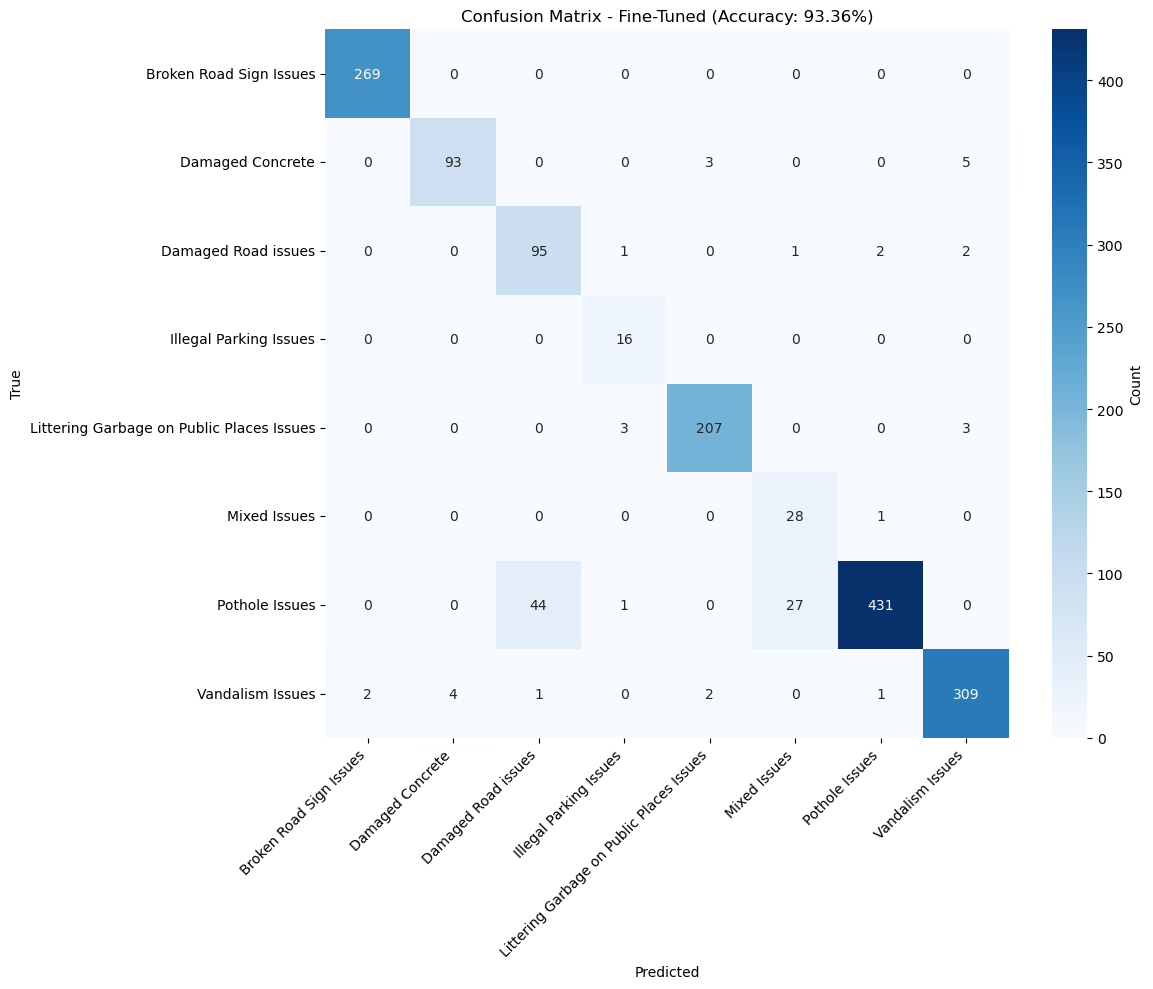

In [13]:
# Evaluate Fine-tuned model on test set
print("Evaluating fine-tuned model on test set...")
model.eval()
ft_preds, ft_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        ft_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        ft_labels.extend(labels.cpu().numpy())

test_acc_ft = accuracy_score(ft_labels, ft_preds)

print("\n" + "="*70)
print("FINE-TUNED TEST SET RESULTS")
print("="*70)
print(f"Accuracy: {test_acc_ft*100:.2f}%\n")

if test_acc_ft >= 0.90:
    print('\n✓✓✓ MODEL EXCEEDS 90% ACCURACY ✓✓✓\n')
    
print(classification_report(ft_labels, ft_preds, target_names=class_names_sorted, digits=4))

# Confusion matrix for Fine-tuned model
cm_ft = confusion_matrix(ft_labels, ft_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_sorted,
            yticklabels=class_names_sorted,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Fine-Tuned (Accuracy: {test_acc_ft*100:.2f}%)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()